<a href="https://colab.research.google.com/github/Churrascooo/Practica-1/blob/main/CODIGOFINAL/Fase4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explicación de la fase

La fase 4 consiste en crear los outcomes que se usarán para predecir. En este caso, son 2: el **evento coronario agudo** y **mortalidad por evento coronario agudo**.
Para la creación del primero se usa el diccionario ICD. Como se puede ver, hay una versión 9 y 10. La razón de esto es que como MIMIC es una base de datos de muchos años, la versión de los diccionarios fueron actualizando con el tiempo, pasando de 9 a 10 (la más reciente).
El outcome del evento coronario agudo se crea con síntomas y diagnósticos relacionados a esta enfermedad.

Para la creación del outcome de mortalidad por evento coronario agudo se trabaja con las columnas **target_coronary_acute** y **hospital_expire_flag**. MIMIC-IV de por sí trae dichas columnas como binarias (1 = mortalidad, 0 = no), por lo que el trabajo es directo.

Por último se unen ambos outcomes para hacer un análisis.

# Importación y cargado de herramientas necesarias

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "/content/drive/MyDrive/mimic_outputs"

Mounted at /content/drive


In [ ]:
#Cohorte base
base_patient = pd.read_parquet(
    os.path.join(OUT_DIR, "cohort_hosp_60.parquet")
)

dx_clean = pd.read_parquet(
    os.path.join(OUT_DIR, "dx_clean_index.parquet")
)

patient_comorb = pd.read_parquet(
    os.path.join(OUT_DIR, "patient_comorb_top5.parquet")
)

print("base_patient:", base_patient.shape)
print("dx_clean:", dx_clean.shape)
print("patient_comorb:", patient_comorb.shape)

base_patient: (111122, 11)
dx_clean: (1595872, 7)
patient_comorb: (111122, 6)


In [ ]:
#Comprueba que un DataFrame tenga exactamente una fila por paciente (subject_id)
#Si hay duplicados, lanza un error para detener el pipeline
def check_unique(df, key="subject_id", name="df"):
    n_rows = len(df) #Número total de filas
    n_uniq = df[key].nunique(dropna=False) #Número de IDs únicos
    print(f"[{name}] filas={n_rows:,} | {key} únicos={n_uniq:,}")

    #1 fila = 1 paciente
    assert n_rows == n_uniq, (
        f"{name} NO es 1 fila por {key}. "
        f"Duplicados: {n_rows - n_uniq:,}"
    )
    print(f"OK: {name} es 1 fila por {key}\n")

# Creación variable objetivo - Evento coronario agudo

In [ ]:
#Se aseguran tipos consistentes (para que los filtros por prefijo funcionen bien)
dx_tmp = dx_clean[["subject_id", "icd_code", "icd_version"]].copy()  #Se hace una copia para no usar dx_clean
dx_tmp["icd_code"] = dx_tmp["icd_code"].astype(str) #Necesario para usar .str.startswith()
dx_tmp["icd_version"] = pd.to_numeric(dx_tmp["icd_version"], errors="coerce") #Convertir a numérico. Si hay basura = queda como NaN

#ICD-10: Infarto agudo (I21), subsecuente (I22), complicaciones (I23), otros SCA (I24) (síndrome coronario agudo)
icd10_acs_prefixes = ("I21", "I22", "I23", "I24")

#ICD-9: Infarto agudo (410), otros relacionados agudos (411)
icd9_acs_prefixes = ("410", "411")

#Máscaras booleanas, las cuales detectan diagnósticos que empiezan por esos prefijos según versión ICD
is_acs_icd10 = (dx_tmp["icd_version"] == 10) & dx_tmp["icd_code"].str.startswith(icd10_acs_prefixes)
is_acs_icd9  = (dx_tmp["icd_version"] == 9)  & dx_tmp["icd_code"].str.startswith(icd9_acs_prefixes)

#Se quedan los subject_id que cumplen ACS (síndrome coronario agudo) al menos una vez (sin duplicarse)
dx_acs = dx_tmp[is_acs_icd10 | is_acs_icd9][["subject_id"]].drop_duplicates()
dx_acs["target_coronary_acute"] = 1  #Etiqueta binaria: si aparece aquí, el outcome es 1

#Base 1 fila por paciente, se hace left join para conservar todos los pacientes
outcome_coronary = base_patient[["subject_id"]].merge(
    dx_acs,
    on="subject_id",
    how="left",
    validate="one_to_one" #1 fila por subject_id
)

#Rellenar NaN -> 0 (pacientes sin el evento coronario y derivados) y dejar como int
outcome_coronary["target_coronary_acute"] = (
    outcome_coronary["target_coronary_acute"].fillna(0).astype(int)
)

#Validación para que quede exactamente 1 fila por subject_id
check_unique(outcome_coronary, key="subject_id", name="outcome_coronary")

#Prevalencia rápida del outcome (proporción de 0 y 1)
outcome_coronary["target_coronary_acute"].value_counts(normalize=True)

[outcome_coronary] filas=111,122 | subject_id únicos=111,122
OK: outcome_coronary es 1 fila por subject_id



,proportion
target_coronary_acute,
0,0.927008
1,0.072992


In [ ]:
#Guardado

outcome_coronary.to_parquet(
    os.path.join(OUT_DIR, "outcome_coronary_acute.parquet"),
    index=False
)

print("Outcome coronario agudo guardado en:", OUT_DIR)

Outcome coronario agudo guardado en: /content/drive/MyDrive/mimic_outputs


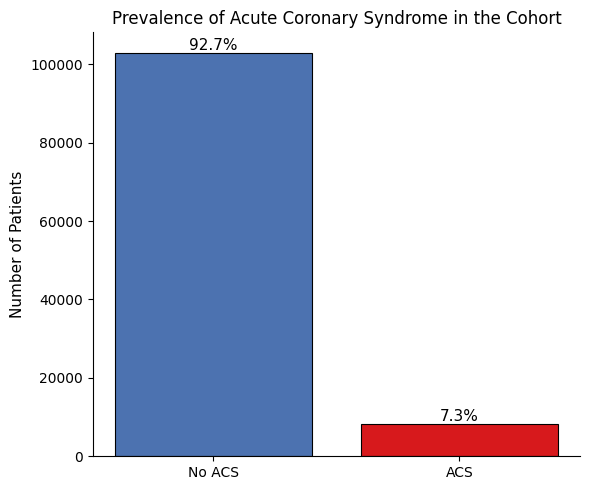

In [ ]:
#Conteos de pacientes con y sin ACS
counts = outcome_coronary["target_coronary_acute"].value_counts().sort_index()
total = counts.sum()
percentages = counts / total * 100

#Etiquetas para el gráfico
labels = ["No ACS", "ACS"]  # 0 = No ACS, 1 = ACS
values = [counts.get(0, 0), counts.get(1, 0)]  # Garantiza que siempre haya ambos valores

#Crear figura tamaño paper
plt.figure(figsize=(6,5))

#Dibujar barras con estilo sobrio
bars = plt.bar(
    labels,
    values,
    color=["#4C72B0", "#D7191C"],
    edgecolor="black",
    linewidth=0.8
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Agregar porcentaje sobre cada barra
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

#Configuración del gráfico
plt.title(
    "Prevalence of Acute Coronary Syndrome in the Cohort",
    fontsize=12
)
plt.ylabel("Number of Patients", fontsize=11)
plt.xlabel("")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("acs_prevalence.pdf", bbox_inches="tight", facecolor="white")
plt.show()

# Creación variable objetivo - Mortalidad por evento coronario agudo

In [ ]:
#Mortalidad asociada a evento coronario agudo

#Se parte desde la cohorte base para asegurar 1 fila por paciente
outcome_death_coronary = base_patient[
    ["subject_id", "hospital_expire_flag"]
].copy()

#Se une el outcome de evento coronario agudo
outcome_death_coronary = outcome_death_coronary.merge(
    outcome_coronary[["subject_id", "target_coronary_acute"]],
    on="subject_id",
    how="left",
    validate="one_to_one"
)

#Asegurar binarios limpios
outcome_death_coronary["hospital_expire_flag"] = (
    outcome_death_coronary["hospital_expire_flag"]
    .fillna(0)
    .astype(int)
)

outcome_death_coronary["target_coronary_acute"] = (
    outcome_death_coronary["target_coronary_acute"]
    .fillna(0)
    .astype(int)
)

#Definición del nuevo outcome
#Muerte intrahospitalaria SOLO si hubo evento coronario agudo
outcome_death_coronary["target_death_coronary_acute"] = (
    (outcome_death_coronary["hospital_expire_flag"] == 1) &
    (outcome_death_coronary["target_coronary_acute"] == 1)
).astype(int)

#Se queda solo con lo necesario
outcome_death_coronary = outcome_death_coronary[
    ["subject_id", "target_death_coronary_acute"]
].copy()

#Validación para tener 1 fila por paciente
check_unique(
    outcome_death_coronary,
    key="subject_id",
    name="outcome_death_coronary_acute"
)

#Prevalencia rápida
outcome_death_coronary["target_death_coronary_acute"].value_counts(normalize=True)

[outcome_death_coronary_acute] filas=111,122 | subject_id únicos=111,122
OK: outcome_death_coronary_acute es 1 fila por subject_id



,proportion
target_death_coronary_acute,
0,0.985457
1,0.014543


In [ ]:
#Guardado

outcome_death_coronary.to_parquet(
    os.path.join(OUT_DIR, "outcome_death_coronary_acute.parquet"),
    index=False
)

print("Outcome mortalidad por evento coronario guardado en:", OUT_DIR)

Outcome mortalidad por evento coronario guardado en: /content/drive/MyDrive/mimic_outputs


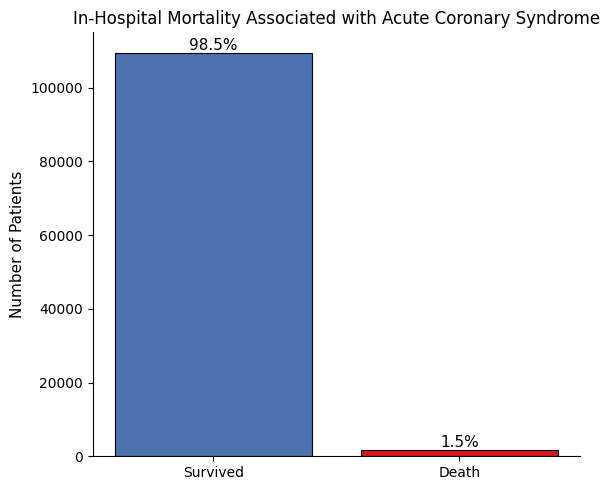

In [ ]:
#Conteos de pacientes con y sin muerte asociada a evento coronario agudo
counts = outcome_death_coronary["target_death_coronary_acute"].value_counts().sort_index()
total = counts.sum()
percentages = counts / total * 100

#Etiquetas para el gráfico
labels = ["Survived", "Death"]  # 0 = survived, 1 = death
values = [counts.get(0, 0), counts.get(1, 0)] #Se garantiza que siempre haya ambos valores

#Crear figura tamaño paper
plt.figure(figsize=(6,5))

#Dibujar barras con estilo sobrio
bars = plt.bar(
    labels,
    values,
    color=["#4C72B0", "#D7191C"],
    edgecolor="black",
    linewidth=0.8
)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Agregar porcentaje sobre cada barra
for bar, pct in zip(bars, percentages):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

#Configuración del gráfico
plt.title(
    "In-Hospital Mortality Associated with Acute Coronary Syndrome",
    fontsize=12
)
plt.ylabel("Number of Patients", fontsize=11)
plt.xlabel("")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig("death_coronary_acute.pdf", bbox_inches="tight", facecolor="white")
plt.show()

# Unir ambos outcomes

In [ ]:
#Unir ambos outcomes

outcomes = (
    outcome_coronary
    .merge(
        outcome_death_coronary,
        on="subject_id",
        how="inner",
        validate="one_to_one"
    )
)

#Validación estructural
check_unique(outcomes, key="subject_id", name="outcomes")

[outcomes] filas=111,122 | subject_id únicos=111,122
OK: outcomes es 1 fila por subject_id



In [ ]:
#Tabla de contingencia
#Evento coronario vs mortalidad asociada al evento

ct = pd.crosstab(
    outcomes["target_coronary_acute"],
    outcomes["target_death_coronary_acute"],
    rownames=["Acute coronary event"],
    colnames=["Death due to ACS"]
)

ct

Death due to ACS,0,1
Acute coronary event,,
0,103011,0
1,6495,1616


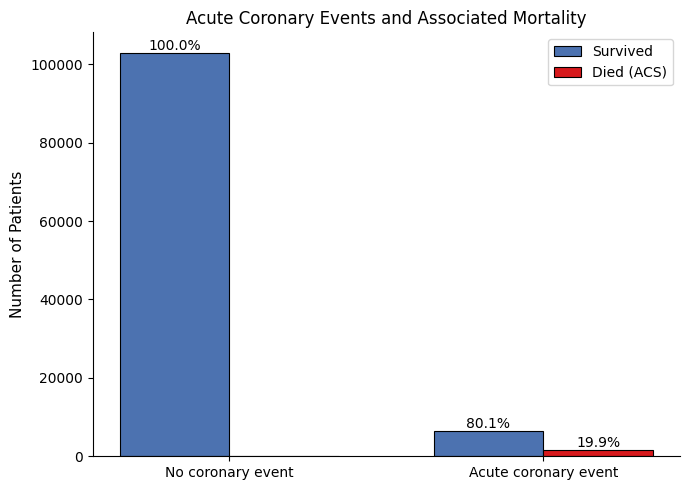

In [ ]:
#Datos para gráfico de barras
bar_data = pd.DataFrame(
    {
        "Survived": [
            ct.loc[0, 0],
            ct.loc[1, 0]
        ],
        "Died (ACS)": [
            0, # Sin el evento no puede haber muerte por ACS
            ct.loc[1, 1]
        ]
    },
    index=["No coronary event", "Acute coronary event"]
)

#Calcular porcentajes para mostrar sobre cada barra
total_per_group = bar_data.sum(axis=1)
percentages = bar_data.div(total_per_group, axis=0) * 100

#Crear figura estilo paper
plt.figure(figsize=(7,5))

#Posición de barras
x = np.arange(len(bar_data.index))
width = 0.35

#Dibujar barras agrupadas
bars1 = plt.bar(x - width/2, bar_data["Survived"], width, label="Survived", color="#4C72B0", edgecolor="black", linewidth=0.8)
bars2 = plt.bar(x + width/2, bar_data["Died (ACS)"], width, label="Died (ACS)", color="#D7191C", edgecolor="black", linewidth=0.8)

#Quitar bordes superior y derecho
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#Agregar porcentaje sobre cada barra
for bars, col in zip([bars1, bars2], bar_data.columns):
    for bar, group in zip(bars, bar_data.index):
        height = bar.get_height()
        pct = percentages.loc[group, col]
        if height > 0:  # solo mostrar si hay barra
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10
            )

#Configuración del gráfico
plt.xticks(x, bar_data.index, rotation=0, fontsize=10)
plt.ylabel("Number of Patients", fontsize=11)
plt.title("Acute Coronary Events and Associated Mortality", fontsize=12)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("acs_events_mortality.pdf", bbox_inches="tight", facecolor="white")
plt.show()

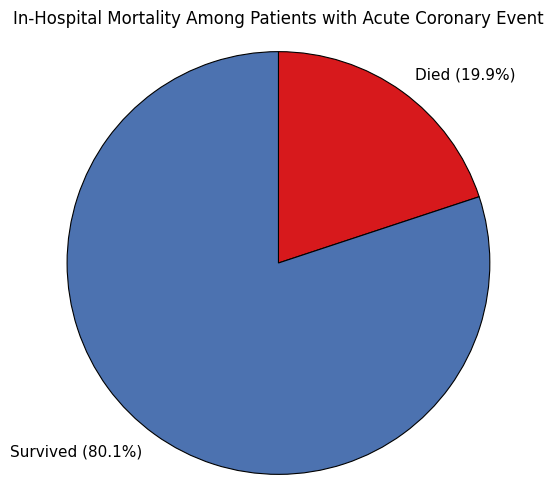

In [ ]:
#Filtrar solo pacientes con evento coronario agudo
acs_patients = outcomes.query("target_coronary_acute == 1")

#Conteos de mortalidad
acs_counts = acs_patients["target_death_coronary_acute"].value_counts()
sizes = [
    acs_counts.get(1, 0),  # Died
    acs_counts.get(0, 0)   # Survived
]

#Etiquetas con porcentaje
total = sum(sizes)
labels = [
    f"Died ({sizes[0] / total * 100:.1f}%)",
    f"Survived ({sizes[1] / total * 100:.1f}%)"
]

#Colores sobrios consistentes con otros gráficos
colors = ["#D7191C", "#4C72B0"]  # Rojo = muerte, Azul = sobrevivió

#Crear gráfico de torta estilo paper
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8},
    textprops={"fontsize": 11}
)

#Asegurar proporción igual para círculo perfecto
plt.axis("equal")

#Título
plt.title("In-Hospital Mortality Among Patients with Acute Coronary Event", fontsize=12)
plt.savefig("acs_inhospital_mortality_pie.pdf", bbox_inches="tight", facecolor="white")
plt.show()

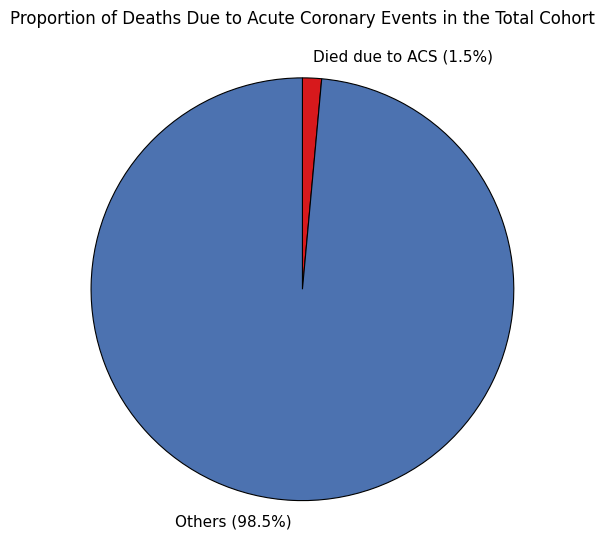

In [ ]:
#Conteos en la cohorte completa
total_counts = outcomes["target_death_coronary_acute"].value_counts()

sizes = [
    total_counts.get(1, 0),  # Died due to ACS
    total_counts.get(0, 0)   # Others
]

#Etiquetas con porcentaje
total = sum(sizes)
labels = [
    f"Died due to ACS ({sizes[0] / total * 100:.1f}%)",
    f"Others ({sizes[1] / total * 100:.1f}%)"
]

#Colores sobrios consistentes
colors = ["#D7191C", "#4C72B0"]  # Rojo = muertes, Azul = otros

#Crear gráfico de torta estilo paper
plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "black", "linewidth": 0.8},
    textprops={"fontsize": 11}
)

#Asegurar proporción igual para círculo perfecto
plt.axis("equal")

#Título
plt.title(
    "Proportion of Deaths Due to Acute Coronary Events in the Total Cohort",
    fontsize=12,
    pad=25
)

plt.savefig("acs_death_proportion_total.pdf", bbox_inches="tight", facecolor="white")
plt.show()